# Load data

In [65]:
import pandas as pd

In [66]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

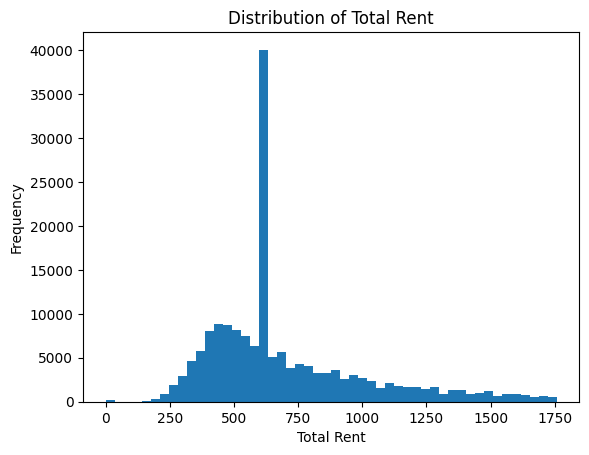

In [67]:
import matplotlib.pyplot as plt

plt.hist(train_df['totalRent'], bins=50)
plt.title("Distribution of Total Rent")
plt.xlabel("Total Rent")
plt.ylabel("Frequency")
plt.show()

The distribution of totalRent is highly right-skewed, with the majority of values concentrated between 400 and 700, and a long tail extending toward higher values up to around 1800. This indicates the presence of high-value outliers.

Additionally, a prominent peak around 600 suggests a dense region of typical rental values. Due to this skewness and the influence of outliers, the mean would be biased toward higher values.

Therefore, the median (approximately 622) is chosen as the threshold for constructing the binary target variable, as it provides a more robust and representative split of the data.

In [68]:
threshold = 622

train_df["rent_level"] = (train_df["totalRent"] >= threshold).astype(int)
val_df["rent_level"] = (val_df["totalRent"] >= threshold).astype(int)
test_df["rent_level"] = (test_df["totalRent"] >= threshold).astype(int)

In [69]:
target = ['rent_level']

X_train = train_df.drop(columns=['rent_level', 'totalRent'])
y_train = train_df['rent_level']

X_val = val_df.drop(columns=['rent_level', 'totalRent'])
y_val = val_df['rent_level']

X_test = test_df.drop(columns=['rent_level', 'totalRent'])
y_test = test_df['rent_level']

results_final = []

We perform a classification task to determine whether an apartment in Germany belongs to the high-price or low-price category, based on the predicted total rent. Since `totalRent` is directly related to the target variable, we remove this feature from the input set to avoid data leakage. 

Instead, we construct a binary target variable `rent_level`, defined using the median value of `totalRent` (approximately 622) as the threshold: apartments with `totalRent` above this value are labeled as 1 (high price), and those below are labeled as 0 (low price).

# Decision Tree

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

params = [
    (3, 10),
    (5, 20),
    (7, 20),
    (10, 20),
    (5, 50),
    (7, 50)
]

for depth, leaf in params:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"max_depth={depth}, min_leaf={leaf} → Acc={acc:.4f}, F1={f1:.4f}")

max_depth=3, min_leaf=10 → Acc=0.8999, F1=0.9120
max_depth=5, min_leaf=20 → Acc=0.9052, F1=0.9158
max_depth=7, min_leaf=20 → Acc=0.9105, F1=0.9215
max_depth=10, min_leaf=20 → Acc=0.9130, F1=0.9241
max_depth=5, min_leaf=50 → Acc=0.9052, F1=0.9158
max_depth=7, min_leaf=50 → Acc=0.9103, F1=0.9214


In [71]:
best_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.9130, Test F1 Score: 0.9240


In [73]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

baseRent                                      0.888257
serviceCharge                                 0.051947
livingSpace                                   0.015605
regio2_freq                                   0.009517
regio1_nordrhein_westfalen                    0.004460
regio1_niedersachsen                          0.003922
condition_unknown                             0.003741
heatingType_self_contained_central_heating    0.003589
heatingType_district_heating                  0.002359
yearConstructed                               0.002084
dtype: float64


### Maybe it is Data Leakage

In [74]:
X_train = X_train.drop(columns=['baseRent'])
X_val = X_val.drop(columns=['baseRent'])
X_test = X_test.drop(columns=['baseRent'])

## Why `baseRent` Was Removed

`baseRent` was removed to prevent **data leakage**.

The target variable (`buy_house`) is derived from `totalRent`, while:

```
totalRent ≈ baseRent + serviceCharge
```

This means `baseRent` contains direct information about the target. When included, the model relies heavily on it instead of learning meaningful patterns, leading to artificially high performance.

After removing `baseRent`, the model becomes:

* More realistic
* More interpretable
* Based on actual features (e.g., living space, price trend)

Although performance decreases, the model is **more reliable and valid**.


In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

params = [
    (3, 10),
    (5, 20),
    (7, 20),
    (10, 20),
    (5, 50),
    (7, 50)
]

for depth, leaf in params:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"max_depth={depth}, min_leaf={leaf} → Acc={acc:.4f}, F1={f1:.4f}")

max_depth=3, min_leaf=10 → Acc=0.7918, F1=0.8101
max_depth=5, min_leaf=20 → Acc=0.8108, F1=0.8346
max_depth=7, min_leaf=20 → Acc=0.8244, F1=0.8443
max_depth=10, min_leaf=20 → Acc=0.8447, F1=0.8681
max_depth=5, min_leaf=50 → Acc=0.8106, F1=0.8344
max_depth=7, min_leaf=50 → Acc=0.8248, F1=0.8447


In [76]:
best_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}")

results_final.append({
    "model": "Decision Tree",
    "test_accuracy": test_acc,
    "test_f1": test_f1
})

Test Accuracy: 0.8450, Test F1 Score: 0.8686


# Logistic Regression

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000, random_state=0))
])
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [79]:
y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 83.93%


In [80]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80     17318
           1       0.87      0.86      0.86     25698

    accuracy                           0.84     43016
   macro avg       0.83      0.83      0.83     43016
weighted avg       0.84      0.84      0.84     43016

[[13959  3359]
 [ 3554 22144]]


In [81]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100
print(f"Logistic Regression model accuracy on test set: {acc:.2f}%")
results_final.append({
    "model": "Logistic Regression",
    "test_accuracy": acc / 100,
    "test_f1": f1_score(y_test, y_pred)
})

Logistic Regression model accuracy on test set: 83.98%


In [82]:
model_ = model.named_steps["clf"]
weights = model_.coef_[0]  
feature_cols = X_train.columns.tolist()
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "weight": weights
})

coef_df = coef_df.sort_values(by="weight", ascending=False)

print(coef_df)

                       feature    weight
4                  livingSpace  1.554151
2                   pricetrend  0.426173
0                serviceCharge  0.378964
8                   newlyConst  0.237373
58        typeOfFlat_penthouse  0.236294
..                         ...       ...
51           condition_unknown -0.427829
52         condition_well_kept -0.524895
23  regio1_nordrhein_westfalen -0.550399
27       regio1_sachsen_anhalt -0.625860
26              regio1_sachsen -1.030971

[63 rows x 2 columns]


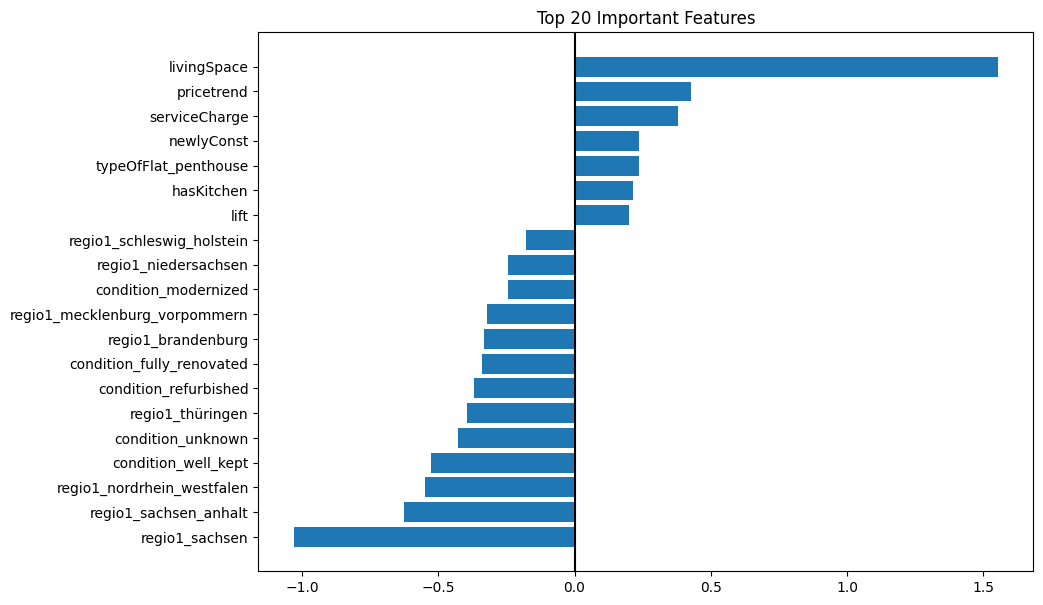

In [83]:
top_k = 20

df = coef_df.copy()
df["abs_weight"] = df["weight"].abs()

top = df.sort_values("abs_weight", ascending=False).head(top_k)
top = top.sort_values("weight")

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["weight"])
plt.axvline(0, color="black")
plt.title(f"Top {top_k} Important Features")
plt.show()

## Gaussian Naive Bayes

In [84]:
prior_list = [
    [0.5, 0.5],
    [0.6, 0.4],
    [0.4, 0.6],
    [0.7, 0.3],
    [0.3, 0.7],
    [0.8, 0.2],
    [0.2, 0.8]
]

In [85]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for priors in prior_list:
    model = GaussianNB(priors=priors)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "priors": priors,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
        "roc_auc": roc_auc_score(y_val, y_prob)
    })

In [86]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results.sort_values("f1", ascending=False)

,priors,accuracy,precision,recall,f1,roc_auc
6,"[0.2, 0.8]",0.704366,0.892009,0.574714,0.699042,0.832595
4,"[0.3, 0.7]",0.701832,0.895623,0.566970,0.694372,0.832708
2,"[0.4, 0.6]",0.699716,0.898783,0.560472,0.690411,0.832762
0,"[0.5, 0.5]",0.697578,0.900714,0.554946,0.686764,0.832782
1,"[0.6, 0.4]",0.695044,0.903205,0.548292,0.682357,0.832797
3,"[0.7, 0.3]",0.691836,0.905594,0.540509,0.676967,0.832846
5,"[0.8, 0.2]",0.688442,0.908451,0.532104,0.671117,0.832904


### 📊 Model Selection based on Priors (GaussianNB)

We evaluated multiple prior settings for Gaussian Naive Bayes and observed the trade-off between precision and recall:

1. **Catch positive cases (maximize Recall)**  
   - Best choice: `priors = [0.2, 0.8]`  
   - Achieves the highest recall → useful when missing positive cases is costly (e.g., fraud detection, medical diagnosis)

2. **Reduce false positives (maximize Precision)**  
   - Best choice: `priors = [0.8, 0.2]`  
   - Achieves the highest precision → useful when false alarms are expensive

3. **Balance Precision & Recall (maximize F1-score)**  
   - Best choice: `priors = [0.2, 0.8]`  
   - Provides the best overall trade-off

---

### ✅ Final Decision

We select the model with:

- `priors = [0.2, 0.8]`

**Reason:**
- Highest Recall → prioritizes detecting positive cases
- Also achieves the highest F1-score → good balance overall

---

### ⚠️ Note

ROC-AUC remains nearly unchanged across different priors, indicating that:
- The model's ranking ability is stable
- Priors mainly affect the decision threshold, not the underlying model quality

In [87]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, log_loss
)

best_model = GaussianNB(priors=[0.2, 0.8])
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=== TEST SET EVALUATION ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("Log Loss :", log_loss(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

results_final.append({
    "model": "Naive Bayes",
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_f1": f1_score(y_test, y_pred)
})

=== TEST SET EVALUATION ===
Accuracy : 0.7026780732750605
Precision: 0.8934450180188955
Recall   : 0.5707263960180432
F1-score : 0.6965204350879858
ROC-AUC  : 0.8325631167299187
Log Loss : 4.0989134030365575

Confusion Matrix:
[[19437  2188]
 [13799 18346]]


## Multi-Layer Perception

In [88]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [89]:
class MLPBinary(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [90]:
input_dim = X_train.shape[1]
print(f"Input dimension: {input_dim}")
model = MLPBinary(input_dim)

criterion = nn.BCELoss()  # Binary cross-entropy
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

Input dimension: 63


In [91]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [92]:
train_losses = []
val_losses = []

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)  
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)      
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/20, Train Loss: 0.3628, Val Loss: 0.3399
Epoch 2/20, Train Loss: 0.3461, Val Loss: 0.3304
Epoch 3/20, Train Loss: 0.3387, Val Loss: 0.3253
Epoch 4/20, Train Loss: 0.3357, Val Loss: 0.3234
Epoch 5/20, Train Loss: 0.3323, Val Loss: 0.3220
Epoch 6/20, Train Loss: 0.3308, Val Loss: 0.3200
Epoch 7/20, Train Loss: 0.3292, Val Loss: 0.3174
Epoch 8/20, Train Loss: 0.3270, Val Loss: 0.3161
Epoch 9/20, Train Loss: 0.3266, Val Loss: 0.3177
Epoch 10/20, Train Loss: 0.3245, Val Loss: 0.3188
Epoch 11/20, Train Loss: 0.3238, Val Loss: 0.3131
Epoch 12/20, Train Loss: 0.3228, Val Loss: 0.3140
Epoch 13/20, Train Loss: 0.3224, Val Loss: 0.3161
Epoch 14/20, Train Loss: 0.3211, Val Loss: 0.3139
Epoch 15/20, Train Loss: 0.3205, Val Loss: 0.3150
Epoch 16/20, Train Loss: 0.3206, Val Loss: 0.3139
Epoch 17/20, Train Loss: 0.3204, Val Loss: 0.3139
Epoch 18/20, Train Loss: 0.3189, Val Loss: 0.3106
Epoch 19/20, Train Loss: 0.3188, Val Loss: 0.3092
Epoch 20/20, Train Loss: 0.3173, Val Loss: 0.3108


In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss

model.eval()
with torch.no_grad():
    y_prob = model(X_test).numpy()
    y_pred = (y_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Log Loss:", log_loss(y_test, y_prob))
results_final.append({
    "model": "MLP",
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_f1": f1_score(y_test, y_pred)
})

Accuracy: 0.862097824065464
Precision: 0.8945185374258184
Recall: 0.8721729662466947
F1: 0.8832044355537354
Confusion Matrix:
 [[18319  3306]
 [ 4109 28036]]
ROC-AUC: 0.9375491653157612
Log Loss: 0.3101340528958235


In [94]:

df = pd.DataFrame(results_final)
df = df.sort_values(by="test_f1", ascending=False)  # sort cho dễ nhìn
print(df)

                 model  test_accuracy   test_f1
3                  MLP       0.862098  0.883204
0        Decision Tree       0.845025  0.868550
1  Logistic Regression       0.839781  0.865837
2          Naive Bayes       0.702678  0.696520


## Visualization

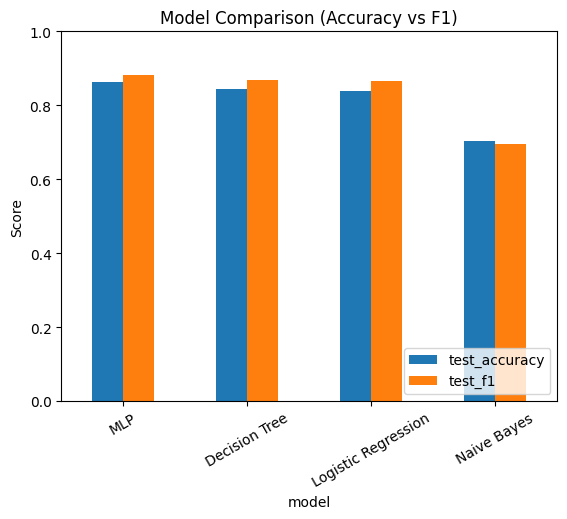

In [95]:
import matplotlib.pyplot as plt

df.set_index("model")[["test_accuracy", "test_f1"]].plot(kind="bar")

plt.title("Model Comparison (Accuracy vs F1)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")

plt.show()

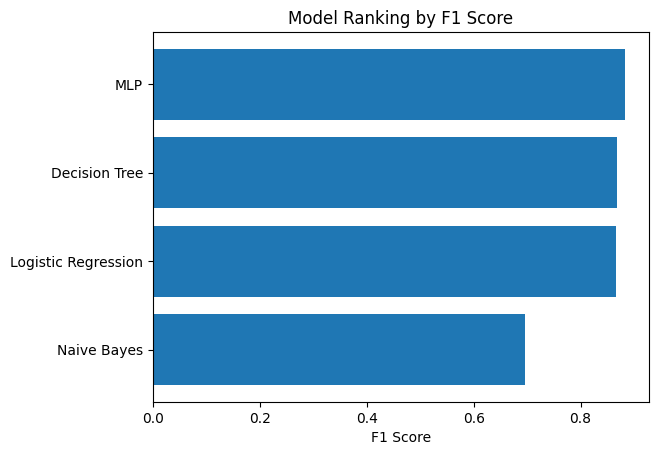

In [96]:
df_sorted = df.sort_values(by="test_f1", ascending=True)

plt.barh(df_sorted["model"], df_sorted["test_f1"])
plt.title("Model Ranking by F1 Score")
plt.xlabel("F1 Score")

plt.show()

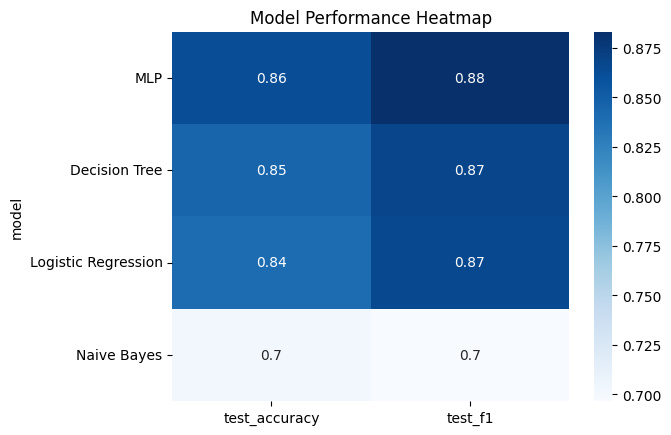

In [97]:
import seaborn as sns

sns.heatmap(df.set_index("model"), annot=True, cmap="Blues")

plt.title("Model Performance Heatmap")
plt.show()